In [13]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

plt.style.use("default")

In [14]:
df = pd.read_csv("../data/train.csv")

print(df.shape)

df.head()

(159571, 8)


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0
3,0001b41b1c6bb37e,"""\nMore\nI can't make any real suggestions on ...",0,0,0,0,0,0
4,0001d958c54c6e35,"You, sir, are my hero. Any chance you remember...",0,0,0,0,0,0


In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 159571 entries, 0 to 159570
Data columns (total 8 columns):
 #   Column         Non-Null Count   Dtype
---  ------         --------------   -----
 0   id             159571 non-null  str  
 1   comment_text   159571 non-null  str  
 2   toxic          159571 non-null  int64
 3   severe_toxic   159571 non-null  int64
 4   obscene        159571 non-null  int64
 5   threat         159571 non-null  int64
 6   insult         159571 non-null  int64
 7   identity_hate  159571 non-null  int64
dtypes: int64(6), str(2)
memory usage: 9.7 MB


In [16]:
df.isnull().sum()

id               0
comment_text     0
toxic            0
severe_toxic     0
obscene          0
threat           0
insult           0
identity_hate    0
dtype: int64

In [17]:
label_cols = [
    "toxic",
    "severe_toxic",
    "obscene",
    "threat",
    "insult",
    "identity_hate"
]

for col in label_cols:
    print(col)
    print(df[col].value_counts())
    print("-" * 40)

toxic
toxic
0    144277
1     15294
Name: count, dtype: int64
----------------------------------------
severe_toxic
severe_toxic
0    157976
1      1595
Name: count, dtype: int64
----------------------------------------
obscene
obscene
0    151122
1      8449
Name: count, dtype: int64
----------------------------------------
threat
threat
0    159093
1       478
Name: count, dtype: int64
----------------------------------------
insult
insult
0    151694
1      7877
Name: count, dtype: int64
----------------------------------------
identity_hate
identity_hate
0    158166
1      1405
Name: count, dtype: int64
----------------------------------------


In [18]:
df["target"] = (
    df[label_cols]
    .sum(axis=1)
    .gt(0)
    .astype(int)
)

df["target"].value_counts()

target
0    143346
1     16225
Name: count, dtype: int64

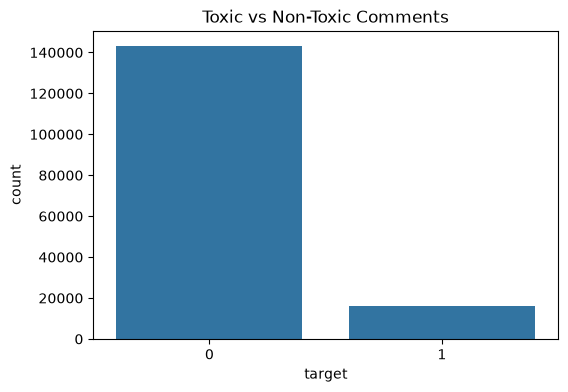

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["target"]
)

plt.title("Toxic vs Non-Toxic Comments")

plt.show()

In [21]:
df["target"].value_counts(normalize=True)* 100

target
0    89.832112
1    10.167888
Name: proportion, dtype: float64

In [22]:
df["char_count"] = (
    df["comment_text"]
    .apply(len)
)

In [23]:
df["word_count"] = (
    df["comment_text"]
    .str.split()
    .apply(len)
)

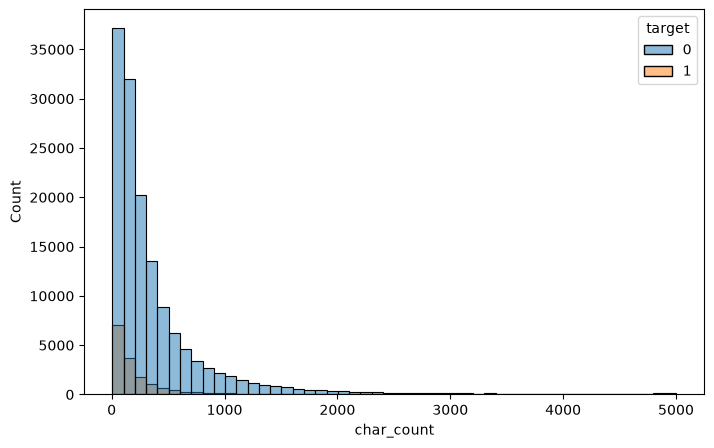

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="char_count",
    hue="target",
    bins=50
)

plt.show()

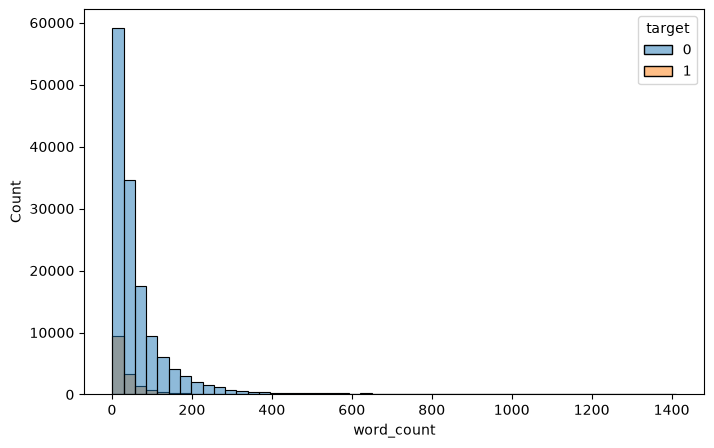

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="word_count",
    hue="target",
    bins=50
)

plt.show()

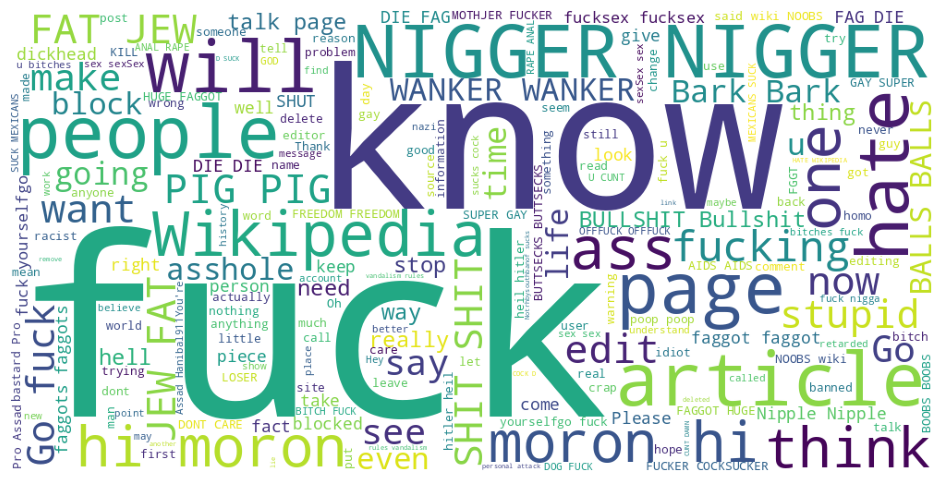

In [26]:
toxic_text = " ".join(
    df[df["target"] == 1]["comment_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(toxic_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

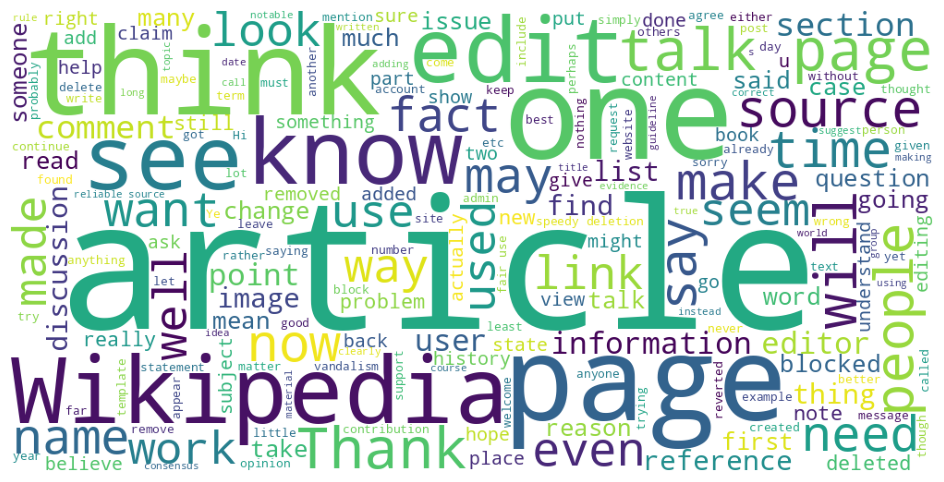

In [27]:
non_toxic_text = " ".join(
    df[df["target"] == 0]["comment_text"]
)

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(non_toxic_text)

plt.figure(figsize=(12,6))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()